In [ ]:
!pip install pydub

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from pydub import AudioSegment
import os

/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


In [ ]:
from google.colab import files

uploaded = files.upload()

file_paths = list(uploaded.keys())
print(file_paths)

Saving Chendamelam_of_Kerala_002.wav to Chendamelam_of_Kerala_002.wav
Saving American_English_unreleased_stops.wav to American_English_unreleased_stops.wav
Saving Clapping_sound_from_Cascabela_thevetia_leaves.wav to Clapping_sound_from_Cascabela_thevetia_leaves.wav
Saving Radio_Oranje_2-jun.-1945_Laatste_uitzending_van_radio_Oranje.wav to Radio_Oranje_2-jun.-1945_Laatste_uitzending_van_radio_Oranje.wav
Saving President_Kennedys_Speech_at_Rice_University.wav to President_Kennedys_Speech_at_Rice_University.wav
Saving Elon_Musk_on_Narendra_Modi.wav to Elon_Musk_on_Narendra_Modi.wav
['Chendamelam_of_Kerala_002.wav', 'American_English_unreleased_stops.wav', 'Clapping_sound_from_Cascabela_thevetia_leaves.wav', 'Radio_Oranje_2-jun.-1945_Laatste_uitzending_van_radio_Oranje.wav', 'President_Kennedys_Speech_at_Rice_University.wav', 'Elon_Musk_on_Narendra_Modi.wav']


In [ ]:
def load_wav(path):
    sr, data = wavfile.read(path)

    # Convert to mono
    if len(data.shape) == 2:
        data = data.mean(axis=1)

    data = data.astype(np.float32)

    max_val = np.max(np.abs(data))
    if max_val > 1:
        data = data / max_val

    return sr, data

In [ ]:
def pcm_quantize(signal, bits):
    L = 2 ** bits

    # Map from [-1,1] → [0, L-1]
    signal_scaled = (signal + 1) / 2 * (L - 1)

    # Quantize (round)
    signal_quantized = np.round(signal_scaled)

    # Map back to [-1,1]
    signal_reconstructed = (signal_quantized / (L - 1)) * 2 - 1

    return np.clip(signal_reconstructed, -1, 1)

In [ ]:
def mu_law_compress(x, mu=255):
    return np.sign(x) * np.log1p(mu * np.abs(x)) / np.log1p(mu)

def mu_law_expand(y, mu=255):
    return np.sign(y) * (np.expm1(np.abs(y) * np.log1p(mu)) / mu)

In [ ]:
def mu_law_process(signal, bits=8, mu=255):
    compressed = mu_law_compress(signal, mu)

    # Quantize compressed signal
    quantized = pcm_quantize(compressed, bits)

    # Expand back
    reconstructed = mu_law_expand(quantized, mu)

    return np.clip(reconstructed, -1, 1)

In [ ]:
def compute_metrics(original, reconstructed):
    mse = np.mean((original - reconstructed) ** 2)

    signal_power = np.mean(original ** 2)
    noise_power = np.mean((original - reconstructed) ** 2)

    snr = 10 * np.log10(signal_power / (noise_power + 1e-10))
    psnr = 10 * np.log10(1 / (mse + 1e-10))  # since range is [-1,1]

    return mse, snr, psnr

In [ ]:
def save_wav(path, sr, signal):
    signal_int16 = np.int16(signal * 32767)
    wavfile.write(path, sr, signal_int16)

In [ ]:
def convert_to_mp3_multi(wav_path, bitrates=["64k", "128k", "320k"]):
    audio = AudioSegment.from_wav(wav_path)

    mp3_paths = {}
    for br in bitrates:
        out_path = wav_path.replace(".wav", f"_{br}.mp3")
        audio.export(out_path, format="mp3", bitrate=br)
        mp3_paths[br] = out_path

    return mp3_paths

In [ ]:
def get_bitrate(mp3_path, sr, signal_length):
    file_size_bits = os.path.getsize(mp3_path) * 8
    duration = signal_length / sr
    return file_size_bits / duration

In [ ]:
def mse_low_amplitude(original, reconstructed, threshold=0.1):
    """
    Compute MSE only where |signal| is small
    """
    mask = np.abs(original) < threshold

    if np.sum(mask) == 0:
        return 0

    return np.mean((original[mask] - reconstructed[mask]) ** 2)

In [ ]:
def energy_compaction(signal):
    spectrum = np.fft.rfft(signal)
    energy = np.abs(spectrum) ** 2

    total_energy = np.sum(energy)

    # Sort descending
    sorted_energy = np.sort(energy)[::-1]

    # cumulative energy
    cumulative = np.cumsum(sorted_energy) / total_energy

    return cumulative

In [ ]:
def plot_energy_compaction(signal, label):
    cumulative = energy_compaction(signal)
    plt.plot(cumulative, label=label)

    plt.figure()
    plot_energy_compaction(signal, "Original")
    plot_energy_compaction(pcm8, "PCM")
    plot_energy_compaction(mulaw, "µ-law")

    plt.title("Energy Compaction")
    plt.xlabel("Number of coefficients")
    plt.ylabel("Cumulative Energy")
    plt.legend()
    plt.show()

In [ ]:
def compute_entropy(signal, bins=256):
    hist, _ = np.histogram(signal, bins=bins, density=False)

    prob = hist / np.sum(hist)   # normalize to probabilities
    prob = prob + 1e-12          # avoid log(0)

    return -np.sum(prob * np.log2(prob))

def redundancy(signal, bits):
    H = compute_entropy(signal)
    return 1 - (H / bits)

In [ ]:
results = []

for path in file_paths:
    print(f"\nProcessing: {path}")

    sr, signal = load_wav(path)

    # PCM
    pcm8 = pcm_quantize(signal, 8)
    mse_pcm, snr_pcm, psnr_pcm = compute_metrics(signal, pcm8)

    # µ-law
    mulaw = mu_law_process(signal, 8)
    mse_mu, snr_mu, psnr_mu = compute_metrics(signal, mulaw)

    # Entropy + Redundancy
    H = compute_entropy(signal)
    red_pcm = 1 - (H / 8)
    red_mulaw = 1 - (H / 8)

    # Save outputs
    save_wav("pcm8_" + path, sr, pcm8)
    save_wav("mulaw_" + path, sr, mulaw)

    # MP3 MULTIPLE BITRATES
    mp3_dict = convert_to_mp3_multi(path)

    for br, mp3_path in mp3_dict.items():
        size_wav = os.path.getsize(path)
        size_mp3 = os.path.getsize(mp3_path)

        cr = size_wav / size_mp3
        bitrate = get_bitrate(mp3_path, sr, len(signal))

        results.append({
            "file": path,
            "method": f"MP3_{br}",
            "Compression_Ratio": cr,
            "Bitrate": bitrate,
            "MSE": None,
            "SNR": None,
            "PSNR": None,
            "Entropy": H,
            "Redundancy": None
        })

    # Add PCM + µ-law entries
    results.append({
        "file": path,
        "method": "PCM_8bit",
        "Compression_Ratio": None,
        "Bitrate": 8 * sr,
        "MSE": mse_pcm,
        "SNR": snr_pcm,
        "PSNR": psnr_pcm,
        "Entropy": H,
        "Redundancy": red_pcm
    })

    results.append({
        "file": path,
        "method": "MuLaw_8bit",
        "Compression_Ratio": None,
        "Bitrate": 8 * sr,
        "MSE": mse_mu,
        "SNR": snr_mu,
        "PSNR": psnr_mu,
        "Entropy": H,
        "Redundancy": red_mulaw
    })

    print("error in low amplitude with mulaw is: ",mse_low_amplitude(signal,mulaw))
    print("error in low amplitude with standard pcm8 is: ", mse_low_amplitude(signal,pcm8))
    print("original entropy was: ", compute_entropy(signal))
    print("redundancy in pcm8 is: ", redundancy(pcm8,8))
    print("redundancy in mulaw is: ", redundancy(mulaw,8))


Processing: Chendamelam_of_Kerala_002.wav
error in low amplitude with mulaw is:  4.417816082852045e-07
error in low amplitude with standard pcm8 is:  5.0927038e-06
original entropy was:  6.230545835495482
redundancy in pcm8 is:  0.2220619284484473
redundancy in mulaw is:  0.23859985433060094

Processing: American_English_unreleased_stops.wav
error in low amplitude with mulaw is:  1.1875695207607807e-07
error in low amplitude with standard pcm8 is:  5.5611954e-06
original entropy was:  4.0346771752327415
redundancy in pcm8 is:  0.49873649273228615
redundancy in mulaw is:  0.5018093631344653

Processing: Clapping_sound_from_Cascabela_thevetia_leaves.wav


/tmp/ipykernel_1443/3194209219.py:2: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr, data = wavfile.read(path)


error in low amplitude with mulaw is:  1.0496985310836987e-08
error in low amplitude with standard pcm8 is:  1.1799677e-05
original entropy was:  1.2583975317007126
redundancy in pcm8 is:  0.8222696501261705
redundancy in mulaw is:  0.8219734204449121

Processing: Radio_Oranje_2-jun.-1945_Laatste_uitzending_van_radio_Oranje.wav


/tmp/ipykernel_1443/3194209219.py:2: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr, data = wavfile.read(path)


error in low amplitude with mulaw is:  2.182827549570355e-07
error in low amplitude with standard pcm8 is:  5.1527236e-06
original entropy was:  4.972247069754191
redundancy in pcm8 is:  0.3848352134122759
redundancy in mulaw is:  0.3873737022441468

Processing: President_Kennedys_Speech_at_Rice_University.wav
error in low amplitude with mulaw is:  2.2758366524399426e-07
error in low amplitude with standard pcm8 is:  5.1139564e-06
original entropy was:  4.9376793549297044
redundancy in pcm8 is:  0.38444465657137883
redundancy in mulaw is:  0.38803825996414765

Processing: Elon_Musk_on_Narendra_Modi.wav
error in low amplitude with mulaw is:  2.500590649078608e-07
error in low amplitude with standard pcm8 is:  5.127908e-06
original entropy was:  5.14070453802479
redundancy in pcm8 is:  0.38127028287951403
redundancy in mulaw is:  0.3658871768490579


In [ ]:
import pandas as pd

df = pd.DataFrame(results)
df

,file,method,Compression_Ratio,Bitrate,MSE,SNR,PSNR,Entropy,Redundancy
0,Chendamelam_of_Kerala_002.wav,MP3_64k,11.024426,64003.386615,NaN,NaN,NaN,6.230546,NaN
1,Chendamelam_of_Kerala_002.wav,MP3_128k,5.512226,128006.457524,NaN,NaN,NaN,6.230546,NaN
2,Chendamelam_of_Kerala_002.wav,MP3_320k,2.204894,320015.662909,NaN,NaN,NaN,6.230546,NaN
3,Chendamelam_of_Kerala_002.wav,PCM_8bit,NaN,352800.000000,5.130476e-06,37.021938,52.898338,6.230546,0.221182
4,Chendamelam_of_Kerala_002.wav,MuLaw_8bit,NaN,352800.000000,4.211550e-06,37.879079,53.755477,6.230546,0.221182
5,American_English_unreleased_stops.wav,MP3_64k,21.995843,64158.259069,NaN,NaN,NaN,4.034677,NaN
6,American_English_unreleased_stops.wav,MP3_128k,10.999179,128301.853393,NaN,NaN,NaN,4.034677,NaN
7,American_English_unreleased_stops.wav,MP3_320k,4.399978,320732.295325,NaN,NaN,NaN,4.034677,NaN
8,American_English_unreleased_stops.wav,PCM_8bit,NaN,352800.000000,5.517249e-06,31.710915,52.582699,4.034677,0.495665
9,American_English_unreleased_stops.wav,MuLaw_8bit,NaN,352800.000000,1.352854e-06,37.815390,58.687170,4.034677,0.495665


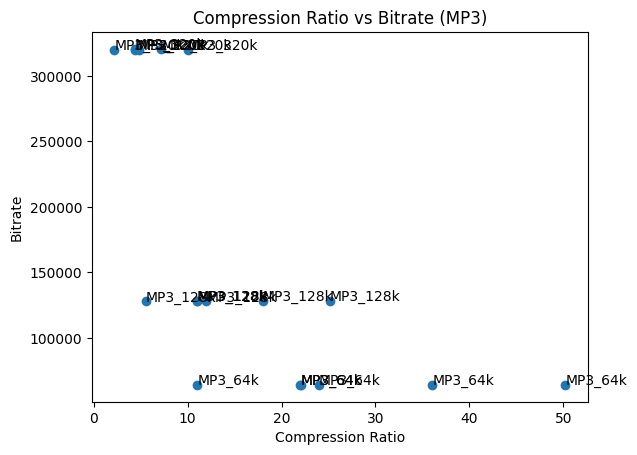

In [ ]:
plt.figure()

mp3_df = df[df["method"].str.contains("MP3")]

plt.scatter(mp3_df["Compression_Ratio"], mp3_df["Bitrate"])

for i, row in mp3_df.iterrows():
    plt.text(row["Compression_Ratio"], row["Bitrate"], row["method"])

plt.xlabel("Compression Ratio")
plt.ylabel("Bitrate")
plt.title("Compression Ratio vs Bitrate (MP3)")
plt.show()

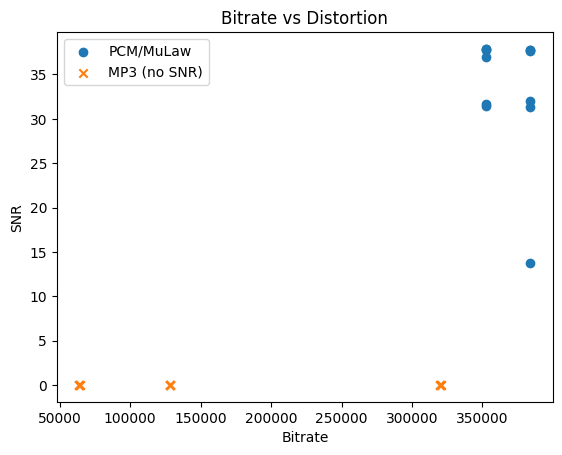

In [ ]:
plt.figure()

# Add SNR from PCM/MuLaw as reference
pcm_mu = df[df["method"].isin(["PCM_8bit", "MuLaw_8bit"])]

plt.scatter(pcm_mu["Bitrate"], pcm_mu["SNR"], label="PCM/MuLaw")

# MP3 (you can optionally decode later for SNR)
mp3_df = df[df["method"].str.contains("MP3")]

plt.scatter(mp3_df["Bitrate"], [0]*len(mp3_df), label="MP3 (no SNR)", marker='x')

plt.xlabel("Bitrate")
plt.ylabel("SNR")
plt.title("Bitrate vs Distortion")
plt.legend()
plt.show()

In [ ]:
plt.figure()

plot_energy_compaction(signal, "Original")
plot_energy_compaction(pcm8, "PCM")
plot_energy_compaction(mulaw, "MuLaw")

plt.title("Energy Compaction Comparison")
plt.xlabel("Coefficients")
plt.ylabel("Cumulative Energy")
plt.legend()
plt.show()

/tmp/ipykernel_1443/4050493097.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


In [ ]:
plt.figure()

# Extract values manually for clarity
pcm_snr = df[df["method"] == "PCM_8bit"]["SNR"].values
mulaw_snr = df[df["method"] == "MuLaw_8bit"]["SNR"].values

labels = df["file"].unique()

x = np.arange(len(labels))

plt.bar(x - 0.2, pcm_snr, width=0.4, label="PCM")
plt.bar(x + 0.2, mulaw_snr, width=0.4, label="µ-law")

plt.xticks(x, labels, rotation=45)
plt.ylabel("SNR (dB)")
plt.title("SNR Comparison: PCM vs µ-law")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
plt.figure()

pcm_mse = df[df["method"] == "PCM_8bit"]["MSE"].values
mulaw_mse = df[df["method"] == "MuLaw_8bit"]["MSE"].values

labels = df["file"].unique()
x = np.arange(len(labels))

plt.bar(x - 0.2, pcm_mse, width=0.4, label="PCM")
plt.bar(x + 0.2, mulaw_mse, width=0.4, label="µ-law")

plt.xticks(x, labels, rotation=45)
plt.ylabel("MSE (log scale)")
plt.yscale("log")
plt.title("MSE Comparison: PCM vs µ-law")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
plt.figure()

# Use only MP3 (since compression ratio meaningful there)
mp3_df = df[df["method"].str.contains("MP3")]

plt.scatter(mp3_df["Entropy"], mp3_df["Compression_Ratio"])

for i, row in mp3_df.iterrows():
    plt.text(row["Entropy"], row["Compression_Ratio"], row["method"])

plt.xlabel("Entropy (bits)")
plt.ylabel("Compression Ratio")
plt.title("Entropy vs Compression Ratio")
plt.show()

In [ ]:
plt.figure()
plt.bar(df["file"], df["PCM_SNR"], label="PCM")
plt.bar(df["file"], df["MuLaw_SNR"], alpha=0.7, label="µ-law")
plt.legend()
plt.xticks(rotation=45)
plt.title("SNR Comparison")
plt.show()